<a href="https://colab.research.google.com/github/pragadeesh1024/social-media-addiction-in-gen-z-/blob/main/teenager_mental_health_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [89]:
df=pd.read_csv('/content/genz_social_media_usage_1M.csv')


In [90]:
df

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,21,Male,India,3.097065,Snapchat,4,Entertainment,21.158532,1,7.230186,Medium,66.317438
999996,14,Male,India,3.663561,Instagram,1,Education,26.312119,1,8.273996,Medium,47.150600
999997,20,Male,India,4.474618,YouTube,2,Socializing,13.623681,0,7.611955,Medium,18.872826
999998,24,Female,Germany,7.829924,YouTube,2,Content Creation,15.789750,1,2.341113,High,62.136012


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ MB


In [92]:
df.isnull().sum()

,0
age,0
gender,0
country,0
daily_usage_hours,0
primary_platform,0
num_platforms_used,0
purpose,0
avg_session_minutes,0
night_usage,0
mental_health_score,0


In [93]:
#encode
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtype=='object':
    df[i]=le.fit_transform(df[i])

In [94]:
from sklearn.impute import SimpleImputer
si=SimpleImputer()
df['primary_platform']=si.fit_transform(df[['primary_platform']])
df['num_platforms_used']=si.fit_transform(df[['num_platforms_used']])
df['purpose']=si.fit_transform(df[['purpose']])
df['avg_session_minutes']=si.fit_transform(df[['avg_session_minutes']])
df['night_usage']=si.fit_transform(df[['night_usage']])
df['mental_health_score']=si.fit_transform(df[['mental_health_score']])
df['addiction_level']=si.fit_transform(df[['addiction_level']])
df['screen_time_before_sleep']=si.fit_transform(df[['screen_time_before_sleep']])
df['daily_usage_hours']=si.fit_transform(df[['daily_usage_hours']])
#null value  filled with knn imputer


In [95]:
df.isnull().sum()

,0
age,0
gender,0
country,0
daily_usage_hours,0
primary_platform,0
num_platforms_used,0
purpose,0
avg_session_minutes,0
night_usage,0
mental_health_score,0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  int64  
 2   country                   1000000 non-null  int64  
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  float64
 5   num_platforms_used        1000000 non-null  float64
 6   purpose                   1000000 non-null  float64
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  float64
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  float64
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 91.6 MB


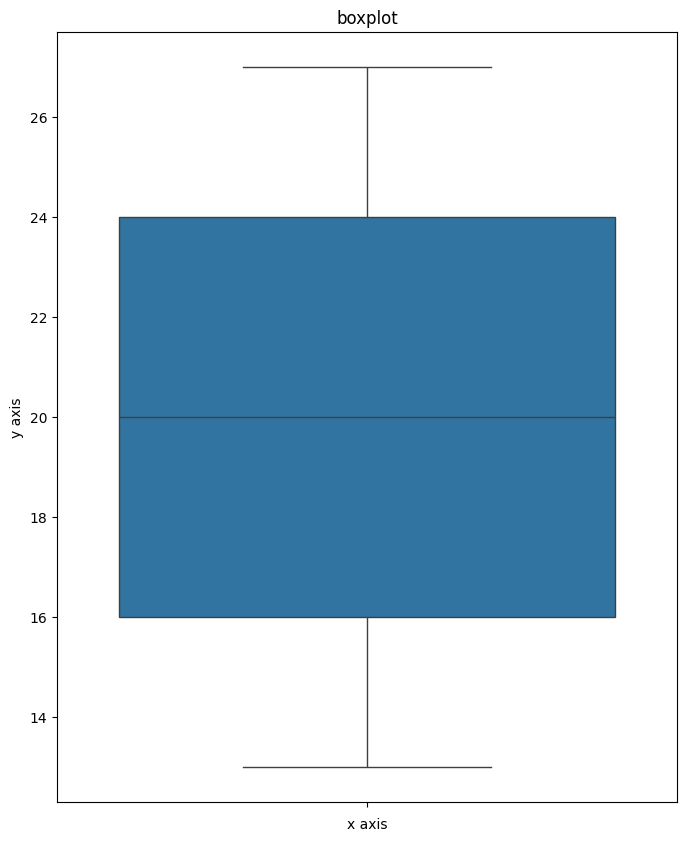

In [97]:
# to cheching outlier in boxplot
plt.figure(figsize=(8,10))
sns.boxplot(df['age'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('boxplot')
plt.show()

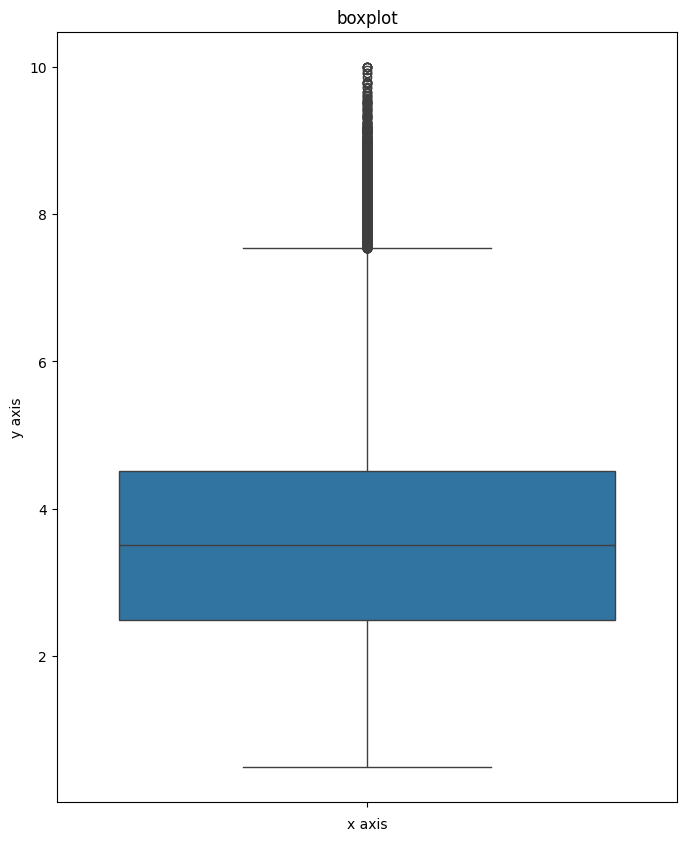

In [98]:
plt.figure(figsize=(8,10))
sns.boxplot(df['daily_usage_hours'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('boxplot')
plt.show()

<Axes: ylabel='daily_usage_hours'>

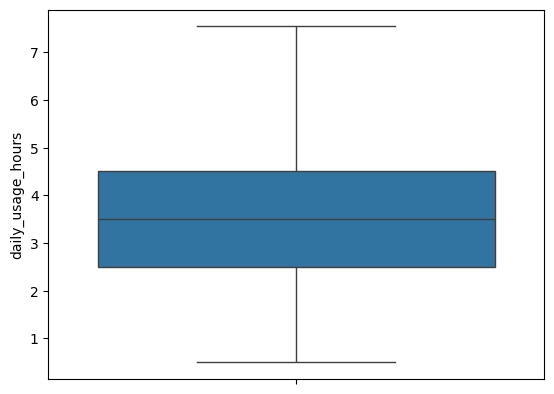

In [99]:
#cap the outlier used iqr method
q1=df['daily_usage_hours'].quantile(0.25)
q3=df['daily_usage_hours'].quantile(0.75)
iqr=q3-q1
u=q3+1.5*iqr
l=q1-1.5*iqr
df['daily_usage_hours']=df['daily_usage_hours'].clip(upper=u,lower=l)
sns.boxplot(df['daily_usage_hours'])

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


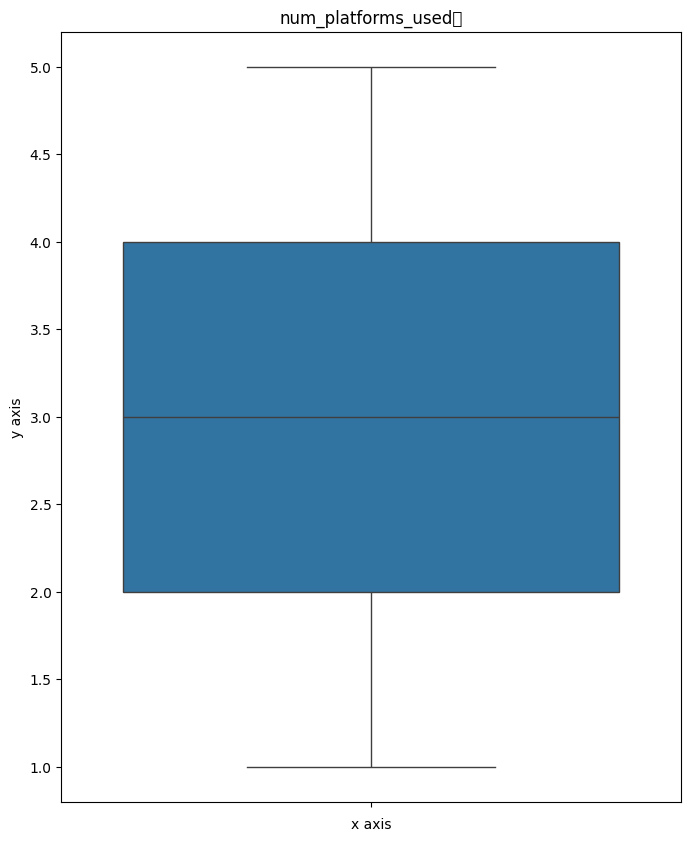

In [100]:
plt.figure(figsize=(8,10))
sns.boxplot(df['num_platforms_used'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('num_platforms_used	')
plt.show()

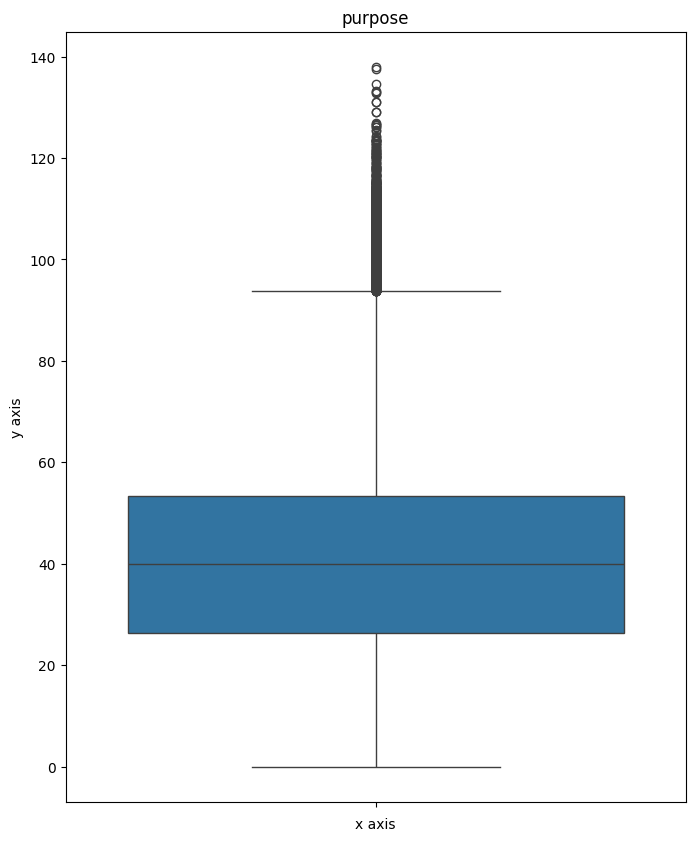

In [101]:
plt.figure(figsize=(8,10))
sns.boxplot(df['screen_time_before_sleep'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('purpose')
plt.show()

<Axes: ylabel='screen_time_before_sleep'>

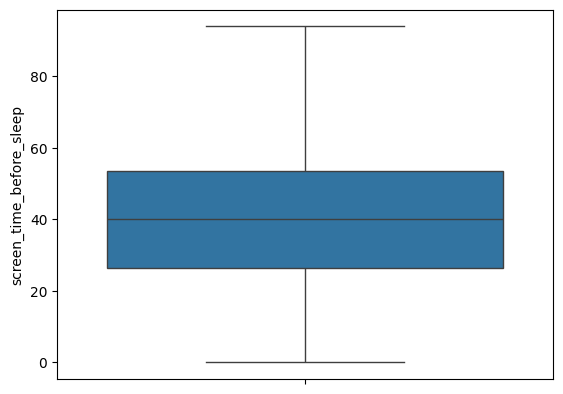

In [102]:
q1=df['screen_time_before_sleep'].quantile(0.25)
q3=df['screen_time_before_sleep'].quantile(0.75)
iqr=q3-q1
u=q3+1.5*iqr
l=q1-1.5*iqr
df['screen_time_before_sleep']=df['screen_time_before_sleep'].clip(upper=u,lower=l)
sns.boxplot(df['screen_time_before_sleep'])

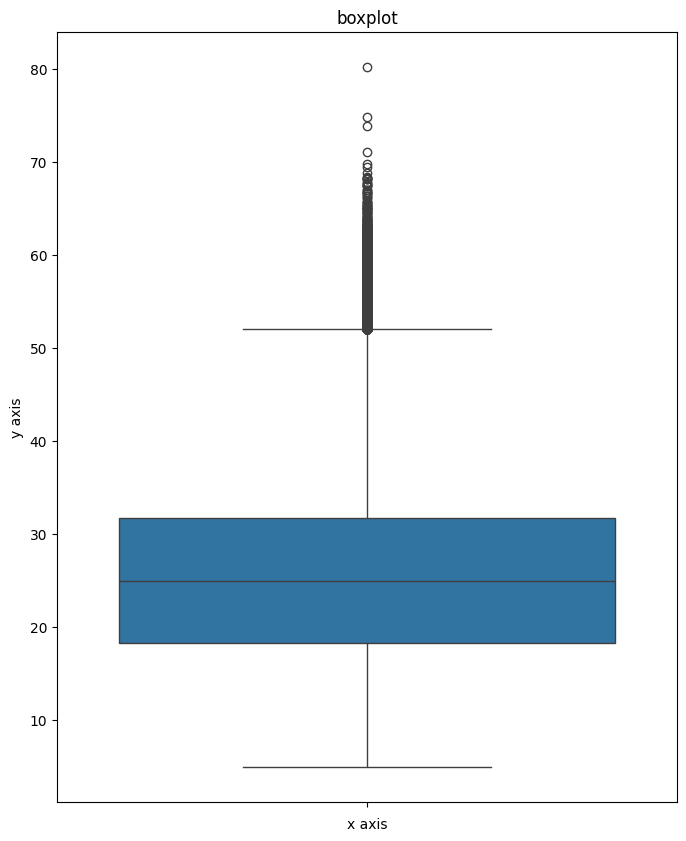

In [103]:
plt.figure(figsize=(8,10))
sns.boxplot(df['avg_session_minutes'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('boxplot')
plt.show()
#

<Axes: ylabel='avg_session_minutes'>

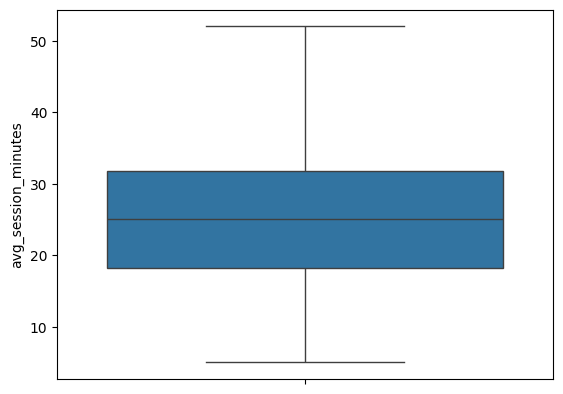

In [104]:
q1=df['avg_session_minutes'].quantile(0.25)
q3=df['avg_session_minutes'].quantile(0.75)
iqr=q3-q1
u=q3+1.5*iqr
l=q1-1.5*iqr
df['avg_session_minutes']=df['avg_session_minutes'].clip(upper=u,lower=l)
sns.boxplot(df['avg_session_minutes'])

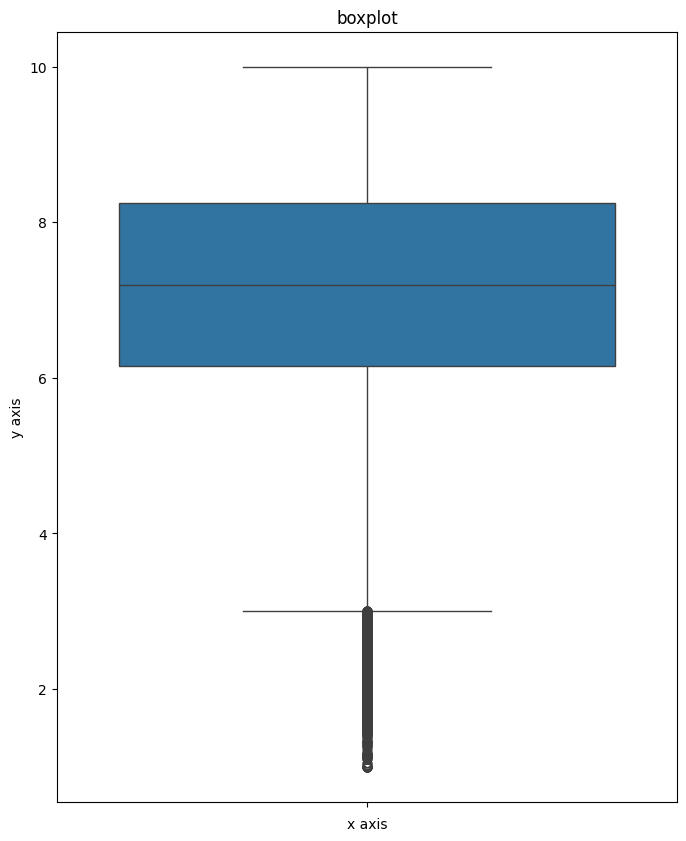

In [105]:
plt.figure(figsize=(8,10))
sns.boxplot(df['mental_health_score'])
plt.xlabel('x axis')
plt.ylabel('y axis')
plt.title('boxplot')
plt.show()

<Axes: ylabel='mental_health_score'>

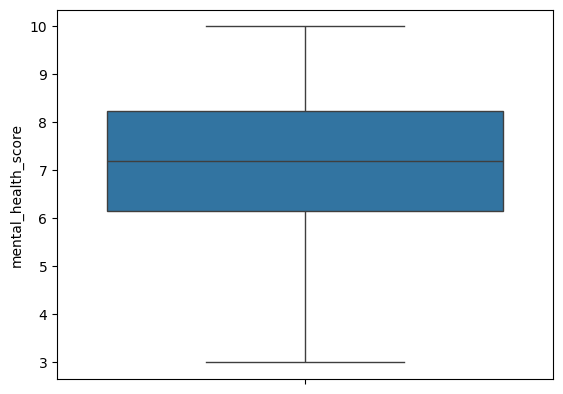

In [106]:
q1=df['mental_health_score'].quantile(0.25)
q3=df['mental_health_score'].quantile(0.75)
iqr=q3-q1
u=q3+1.5*iqr
l=q1-1.5*iqr
df['mental_health_score']=df['mental_health_score'].clip(upper=u,lower=l)
sns.boxplot(df['mental_health_score'])

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  int64  
 2   country                   1000000 non-null  int64  
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  float64
 5   num_platforms_used        1000000 non-null  float64
 6   purpose                   1000000 non-null  float64
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  float64
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  float64
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(9), int64(3)
memory usage: 91.6 MB


In [108]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df['age']=sc.fit_transform(df[['age']])
df['daily_usage_hours']=sc.fit_transform(df[['daily_usage_hours']])
df['num_platforms_used']=sc.fit_transform(df[['num_platforms_used']])
df['screen_time_before_sleep']=sc.fit_transform(df[['screen_time_before_sleep']])
df['avg_session_minutes']=sc.fit_transform(df[['avg_session_minutes']])

df['night_usage']=sc.fit_transform(df[['night_usage']])
df


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,-0.230125,1,0,-0.583926,1.0,0.707290,1.0,0.424573,-1.224638,6.705830,2.0,-1.246932
1,-0.924230,0,6,1.483857,3.0,0.000375,4.0,0.756730,0.816568,6.633111,0.0,0.390485
2,1.158083,0,4,-0.499348,2.0,-0.706539,4.0,-0.707678,0.816568,6.035397,2.0,1.149822
3,1.620820,1,4,-0.018279,4.0,0.707290,1.0,-0.264745,0.816568,8.110861,2.0,-0.418587
4,0.695347,0,4,0.160868,2.0,-1.413454,2.0,0.233611,0.816568,6.658598,2.0,-0.545182
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.232611,1,4,-0.284394,1.0,0.707290,2.0,-0.401538,0.816568,7.230186,2.0,1.344290
999996,-1.386966,1,4,0.102616,0.0,-1.413454,1.0,0.126424,0.816568,8.273996,2.0,0.361553
999997,0.001243,1,4,0.656702,4.0,-0.706539,4.0,-1.173448,-1.224638,7.611955,2.0,-1.088326
999998,0.926715,0,3,2.751931,4.0,-0.706539,0.0,-0.951544,0.816568,3.002701,0.0,1.129897


In [109]:
df

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,-0.230125,1,0,-0.583926,1.0,0.707290,1.0,0.424573,-1.224638,6.705830,2.0,-1.246932
1,-0.924230,0,6,1.483857,3.0,0.000375,4.0,0.756730,0.816568,6.633111,0.0,0.390485
2,1.158083,0,4,-0.499348,2.0,-0.706539,4.0,-0.707678,0.816568,6.035397,2.0,1.149822
3,1.620820,1,4,-0.018279,4.0,0.707290,1.0,-0.264745,0.816568,8.110861,2.0,-0.418587
4,0.695347,0,4,0.160868,2.0,-1.413454,2.0,0.233611,0.816568,6.658598,2.0,-0.545182
...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0.232611,1,4,-0.284394,1.0,0.707290,2.0,-0.401538,0.816568,7.230186,2.0,1.344290
999996,-1.386966,1,4,0.102616,0.0,-1.413454,1.0,0.126424,0.816568,8.273996,2.0,0.361553
999997,0.001243,1,4,0.656702,4.0,-0.706539,4.0,-1.173448,-1.224638,7.611955,2.0,-1.088326
999998,0.926715,0,3,2.751931,4.0,-0.706539,0.0,-0.951544,0.816568,3.002701,0.0,1.129897


In [110]:
core=df.corr()
print(core['daily_usage_hours'].sort_values())
# checking a correlation

mental_health_score        -7.613243e-01
addiction_level            -2.286881e-01
num_platforms_used         -2.335731e-03
age                        -1.365609e-03
country                    -1.182343e-03
primary_platform           -4.874422e-04
night_usage                 5.512045e-07
gender                      7.402322e-05
screen_time_before_sleep    2.375048e-04
purpose                     8.847328e-04
avg_session_minutes         1.112068e-03
daily_usage_hours           1.000000e+00
Name: daily_usage_hours, dtype: float64


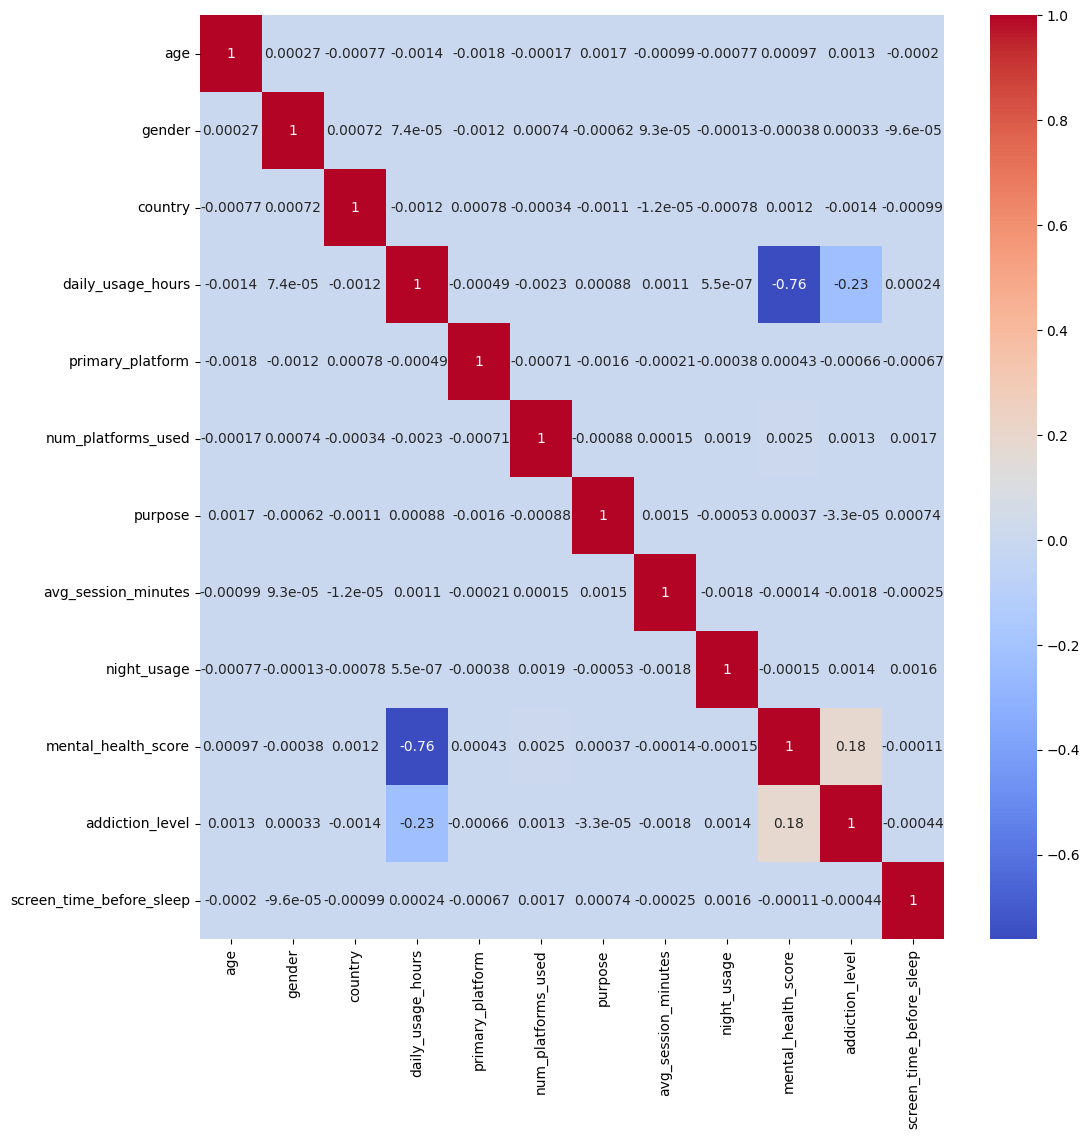

In [111]:
plt.figure(figsize=(12,12))
sns.heatmap(core,annot=True,cmap='coolwarm')
plt.show()
#

In [112]:
df['addiction_level'].value_counts()

,count
addiction_level,
2.0,589843
1.0,251220
0.0,158937


In [113]:
x=df.drop('addiction_level',axis=1)
y=df['addiction_level']
# split a label data

In [114]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=30)

In [115]:
#using undersampling
from imblearn.under_sampling import RandomUnderSampler
rus=RandomUnderSampler()
x_train,y_train=rus.fit_resample(x_train,y_train)

In [116]:
y_train.value_counts()

,count
addiction_level,
0.0,127243
1.0,127243
2.0,127243


In [117]:
# used recursive feature elimination method
# train model in extreme gradient  boosting algorithm
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier

In [118]:

xg=XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,

)
rfe=RFE(estimator=xg,n_features_to_select=12)
rfe.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:300: UserWarning: Found n_features_to_select=12 > n_features=11. There will be no feature selection and all features will be kept.
  warnings.warn(


RFE(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                            colsample_bylevel=None, colsample_bynode=None,
                            colsample_bytree=None, device=None,
                            early_stopping_rounds=None,
                            enable_categorical=False, eval_metric=None,
                            feature_types=None, feature_weights=None,
                            gamma=None, grow_policy=None, importance_type=None,
                            interaction_constraints=None, learning_rate=0.05,
                            max_bin=None, max_cat_threshold=None,
                            max_cat_to_onehot=None, max_delta_step=None,
                            max_depth=None, max_leaves=None,
                            min_child_weight=None, missing=nan,
                            monotone_constraints=None, multi_strategy=None,
                            n_estimators=100, n_jobs=None,
                            num_parallel_tree=None, ...),
    n_features_to_select=12)

In [119]:
print(rfe.support_)
print(rfe.ranking_)

[ True  True  True  True  True  True  True  True  True  True  True]
[1 1 1 1 1 1 1 1 1 1 1]


In [120]:
selected_features=x_train.columns[rfe.support_]
selected_features

Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'screen_time_before_sleep'],
      dtype='object')

In [121]:
pred=rfe.predict(x_test)
pred
#predict the x test value

array([2, 1, 2, ..., 1, 2, 1])

In [122]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,pred)

#checking accuracy score

0.994995

In [123]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)
#checking confusion matrix

array([[ 31681,      0,     13],
       [     0,  50226,     44],
       [   442,    502, 117092]])

In [124]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))
#

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     31694
         1.0       0.99      1.00      0.99     50270
         2.0       1.00      0.99      1.00    118036

    accuracy                           0.99    200000
   macro avg       0.99      1.00      0.99    200000
weighted avg       1.00      0.99      0.99    200000

